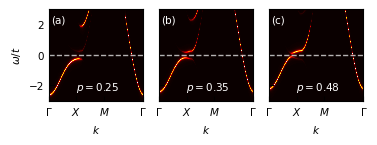

Saved to: C:\Users\fishb\Desktop\fig-spectrum\fermi-arc_sc_spectrum.pdf
Elapsed time: 1.91 s


In [13]:
from pathlib import Path
import os
import time

import matplotlib.pyplot as plt
import numpy as np


# -------------------------- paths --------------------------
data_dir = Path(".").resolve()
os.chdir(data_dir)

style_path = data_dir / "publication.mplstyle"
if style_path.exists():
    plt.style.use(style_path)


# -------------------------- model parameters --------------------------
kB = 1.0
t = 1.0

t1 = -0.2
t2 = 0.1

Q = [np.pi, np.pi]


def band(kx, ky):
    return (
        -2.0 * t * (np.cos(kx) + np.cos(ky))
        - 4.0 * t1 * np.cos(kx) * np.cos(ky)
        - 2.0 * t2 * (np.cos(2.0 * kx) + np.cos(2.0 * ky))
    )


def band_Q(kx, ky):
    return (
        -2.0 * t * (np.cos(kx + Q[0]) + np.cos(ky + Q[1]))
        - 4.0 * t1 * np.cos(kx + Q[0]) * np.cos(ky + Q[1])
        - 2.0 * t2 * (np.cos(2.0 * (kx + Q[0])) + np.cos(2.0 * (ky + Q[1])))
    )


def occupation_Q_per_spin(epsilon, epsilon_Q, mu, U, T):
    epsilon_minus_mu = epsilon - mu
    epsilon_Q_minus_mu = epsilon_Q - mu

    if T < 1e-8:
        T = 1e-8

    beta = 1.0 / T

    E_0 = np.zeros_like(epsilon_minus_mu)
    E_1 = -beta * epsilon_Q_minus_mu
    E_2 = -beta * (epsilon_minus_mu + epsilon_Q_minus_mu + U)
    E_3 = -beta * epsilon_minus_mu

    E_max = np.maximum.reduce([E_0, E_1, E_2, E_3])

    numerator = np.exp(E_1 - E_max) + np.exp(E_2 - E_max)
    denominator = (
        np.exp(E_0 - E_max)
        + np.exp(E_1 - E_max)
        + np.exp(E_2 - E_max)
        + np.exp(E_3 - E_max)
    )

    return numerator / denominator


def average_occupation(mu, T, U, KX, KY, N):
    epsilon = band(KX, KY)
    epsilon_Q = band_Q(KX, KY)

    n_k = occupation_Q_per_spin(epsilon, epsilon_Q, mu, U, T)

    return 2.0 * np.sum(n_k) / N


def k_path_gamma_x_m_gamma(numk):
    gamma_pt = np.array([0.0, 0.0])
    x_pt = np.array([np.pi, 0.0])
    m_pt = np.array([np.pi, np.pi])

    k_gx = np.linspace(gamma_pt, x_pt, numk, endpoint=False, axis=1)
    k_xm = np.linspace(x_pt, m_pt, numk, endpoint=False, axis=1)
    k_mg = np.linspace(m_pt, gamma_pt, numk + 1, axis=1)

    kpath = np.hstack((k_gx, k_xm, k_mg))

    klen = np.zeros(kpath.shape[1])
    for i in range(1, klen.size):
        klen[i] = klen[i - 1] + np.linalg.norm(kpath[:, i] - kpath[:, i - 1])

    xticks = [
        0.0,
        np.linalg.norm(x_pt - gamma_pt),
        np.linalg.norm(x_pt - gamma_pt) + np.linalg.norm(m_pt - x_pt),
        klen[-1],
    ]

    xlabels = [r"$\Gamma$", r"$X$", r"$M$", r"$\Gamma$"]

    return klen, xticks, xlabels


def spectrum_filename(data_dir, U, mu, J):
    return data_dir / f"sc_spectrum_U={U}_mu={mu}J={J}.npy"


# -------------------------- user parameters --------------------------
U = 2
J = 0.8
mu_values = [-1, -1.2, -1.4]

T = 1e-4 * J

Nk = 256
kx_list = np.linspace(-np.pi, np.pi, Nk, endpoint=False)
ky_list = np.linspace(-np.pi, np.pi, Nk, endpoint=False)
KX, KY = np.meshgrid(kx_list, ky_list)
N = Nk * Nk

omega_min = -3.0
omega_max = 3.0
cmap = "hot"

output_pdf = data_dir / "fermi-arc_sc_spectrum.pdf"


# -------------------------- load data --------------------------
spectra = []

for mu in mu_values:
    path = spectrum_filename(data_dir, U, mu, J)
    spectrum_data = np.load(path)
    spectra.append(spectrum_data)

numomega, numk_total = spectra[0].shape
numk = (numk_total - 1) // 3

klen, xticks, xlabels = k_path_gamma_x_m_gamma(numk)

extent = [
    klen[0],
    klen[-1],
    omega_min,
    omega_max,
]


# -------------------------- plot --------------------------
start_time = time.time()

fig, axes = plt.subplots(
    1,
    3,
    figsize=(8.6 / 2.54 * 1.08, 6.3 / 2.54 * 1.08 / 2),
    sharex=True,
    sharey=True,
)

panel_labels = ["(a)", "(b)", "(c)"]

for ax, spectrum_data, mu, label in zip(axes, spectra, mu_values, panel_labels):
    p = 1.0 - average_occupation(mu, T, U, KX, KY, N)

    image = ax.imshow(
        spectrum_data,
        origin="lower",
        aspect="auto",
        extent=extent,
        cmap=cmap,
        interpolation="nearest",
    )

    ax.axhline(
        0.0,
        color="white",
        linestyle="--",
        linewidth=1.0,
        alpha=0.7,
    )

    ax.set_xticks(xticks)
    ax.set_xticklabels(xlabels)
    ax.set_xlabel(r"$k$")

    ax.text(
        0.02,
        0.94,
        label,
        transform=ax.transAxes,
        color="white",
        ha="left",
        va="top",
    )

    ax.text(
        0.75,
        0.22,
        rf"$p={p:.2f}$",
        transform=ax.transAxes,
        color="white",
        ha="right",
        va="top",
    )

axes[0].set_ylabel(r"$\omega/t$")

# cbar = fig.colorbar(image, ax=axes, location="right", shrink=0.95, pad=0.015)
# cbar.set_label(r"$A(\mathbf{k},\omega)$")

fig.savefig(
    output_pdf,
    format="pdf",
    dpi=600,
    bbox_inches="tight",
)

plt.show()

print(f"Saved to: {output_pdf}")
print(f"Elapsed time: {time.time() - start_time:.2f} s")

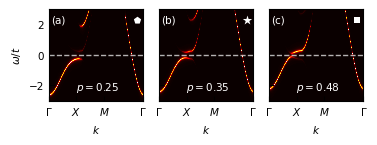

Saved to: C:\Users\fishb\Desktop\sc_spectrum\fermi-arc_sc_spectrum.pdf
Elapsed time: 0.57 s


In [9]:
from pathlib import Path
import os
import time

import matplotlib.pyplot as plt
import numpy as np


# -------------------------- paths --------------------------
data_dir = Path(".").resolve()
os.chdir(data_dir)

style_path = data_dir / "publication.mplstyle"
if style_path.exists():
    plt.style.use(style_path)


# -------------------------- model parameters --------------------------
kB = 1.0
t = 1.0

t1 = -0.2
t2 = 0.1

Q = [np.pi, np.pi]


def band(kx, ky):
    return (
        -2.0 * t * (np.cos(kx) + np.cos(ky))
        - 4.0 * t1 * np.cos(kx) * np.cos(ky)
        - 2.0 * t2 * (np.cos(2.0 * kx) + np.cos(2.0 * ky))
    )


def band_Q(kx, ky):
    return (
        -2.0 * t * (np.cos(kx + Q[0]) + np.cos(ky + Q[1]))
        - 4.0 * t1 * np.cos(kx + Q[0]) * np.cos(ky + Q[1])
        - 2.0 * t2 * (np.cos(2.0 * (kx + Q[0])) + np.cos(2.0 * (ky + Q[1])))
    )


def occupation_Q_per_spin(epsilon, epsilon_Q, mu, U, T):
    epsilon_minus_mu = epsilon - mu
    epsilon_Q_minus_mu = epsilon_Q - mu

    if T < 1e-8:
        T = 1e-8

    beta = 1.0 / T

    E_0 = np.zeros_like(epsilon_minus_mu)
    E_1 = -beta * epsilon_Q_minus_mu
    E_2 = -beta * (epsilon_minus_mu + epsilon_Q_minus_mu + U)
    E_3 = -beta * epsilon_minus_mu

    E_max = np.maximum.reduce([E_0, E_1, E_2, E_3])

    numerator = np.exp(E_1 - E_max) + np.exp(E_2 - E_max)
    denominator = (
        np.exp(E_0 - E_max)
        + np.exp(E_1 - E_max)
        + np.exp(E_2 - E_max)
        + np.exp(E_3 - E_max)
    )

    return numerator / denominator


def average_occupation(mu, T, U, KX, KY, N):
    epsilon = band(KX, KY)
    epsilon_Q = band_Q(KX, KY)
    n_k = occupation_Q_per_spin(epsilon, epsilon_Q, mu, U, T)
    return 2.0 * np.sum(n_k) / N


def k_path_gamma_x_m_gamma(numk):
    gamma_pt = np.array([0.0, 0.0])
    x_pt = np.array([np.pi, 0.0])
    m_pt = np.array([np.pi, np.pi])

    k_gx = np.linspace(gamma_pt, x_pt, numk, endpoint=False, axis=1)
    k_xm = np.linspace(x_pt, m_pt, numk, endpoint=False, axis=1)
    k_mg = np.linspace(m_pt, gamma_pt, numk + 1, axis=1)
    kpath = np.hstack((k_gx, k_xm, k_mg))

    klen = np.zeros(kpath.shape[1])
    for i in range(1, klen.size):
        klen[i] = klen[i - 1] + np.linalg.norm(kpath[:, i] - kpath[:, i - 1])

    xticks = [
        0.0,
        np.linalg.norm(x_pt - gamma_pt),
        np.linalg.norm(x_pt - gamma_pt) + np.linalg.norm(m_pt - x_pt),
        klen[-1],
    ]
    xlabels = [r"$\Gamma$", r"$X$", r"$M$", r"$\Gamma$"]

    return klen, xticks, xlabels


def spectrum_filename(data_dir, U, mu, J):
    return data_dir / f"sc_spectrum_U={U}_mu={mu}J={J}.npy"


# -------------------------- user parameters --------------------------
U = 2
J = 0.8
mu_values = [-1, -1.2, -1.4]
T = 1e-4 * J

Nk = 256
kx_list = np.linspace(-np.pi, np.pi, Nk, endpoint=False)
ky_list = np.linspace(-np.pi, np.pi, Nk, endpoint=False)
KX, KY = np.meshgrid(kx_list, ky_list)
N = Nk * Nk

omega_min = -3.0
omega_max = 3.0
cmap = "hot"

output_pdf = data_dir / "fermi-arc_sc_spectrum.pdf"


# -------------------------- load data --------------------------
spectra = []
for mu in mu_values:
    path = spectrum_filename(data_dir, U, mu, J)
    spectra.append(np.load(path))

numomega, numk_total = spectra[0].shape
numk = (numk_total - 1) // 3
klen, xticks, xlabels = k_path_gamma_x_m_gamma(numk)

extent = [klen[0], klen[-1], omega_min, omega_max]


# -------------------------- plot --------------------------
start_time = time.time()

fig, axes = plt.subplots(
    1,
    3,
    figsize=(8.6 / 2.54 * 1.08, 6.3 / 2.54 * 1.08 / 2),
    sharex=True,
    sharey=True,
)

panel_labels = ["(a)", "(b)", "(c)"]

# 与第一段代码对应：mu=-1 为五边形，mu=-1.2 为星形，mu=-1.4 为方形。
marker_styles = [
    dict(
        s=30,
        marker="p",
        facecolors="white",
        edgecolors="black",
        linewidths=0.0,
        zorder=4,
    ),
    dict(
        s=50,
        marker="*",
        color="white",
        linewidths=0.0,
        zorder=4,
        alpha=1.0,
    ),
    dict(
        s=15,
        marker="s",
        facecolors="white",
        edgecolors="black",
        linewidths=0.0,
        zorder=4,
    ),
]

for ax, spectrum_data, mu, label, marker_style in zip(
    axes, spectra, mu_values, panel_labels, marker_styles
):
    p = 1.0 - average_occupation(mu, T, U, KX, KY, N)

    image = ax.imshow(
        spectrum_data,
        origin="lower",
        aspect="auto",
        extent=extent,
        cmap=cmap,
        interpolation="nearest",
    )

    ax.axhline(
        0.0,
        color="white",
        linestyle="--",
        linewidth=1.0,
        alpha=0.7,
    )

    # 右上区域的 marker，坐标与第一段代码的能带图一致。
    ax.scatter(10.0, 2.3, **marker_style)

    ax.set_xticks(xticks)
    ax.set_xticklabels(xlabels)
    ax.set_xlabel(r"$k$")

    ax.text(
        0.02,
        0.94,
        label,
        transform=ax.transAxes,
        color="white",
        ha="left",
        va="top",
    )

    ax.text(
        0.75,
        0.22,
        rf"$p={p:.2f}$",
        transform=ax.transAxes,
        color="white",
        ha="right",
        va="top",
    )

axes[0].set_ylabel(r"$\omega/t$")

# cbar = fig.colorbar(image, ax=axes, location="right", shrink=0.95, pad=0.015)
# cbar.set_label(r"$A(\mathbf{k},\omega)$")

fig.savefig(
    output_pdf,
    format="pdf",
    dpi=600,
    bbox_inches="tight",
)

plt.show()

print(f"Saved to: {output_pdf}")
print(f"Elapsed time: {time.time() - start_time:.2f} s")
